# Exercise 01

In the first exercise, we have a short introduction to common techniques for geospatial data exploration and preparation

## Import packages

Import the following packages needed for this exercise

- numpy
- pandas
- geopandas
- rasterio
- `train_test-split()` from sklearn.model_selection
- matplotlib


In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio as rio
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Download data
Download the zip file `01_data.zip` from this [folder](https://tubcloud.tu-berlin.de/s/ZX6LbyAQzC5i6RL).
Unzip the folder and place it in a folder called `./data` in the same directory of this exercise.


## Data exploration


**California Housing Data Set**

Many of the Machine Learning Crash Course Programming Exercises use the California housing data set, which contains data drawn from the 1990 U.S. Census. The following link provides descriptions, data ranges, and data types for each feature in the data set: https://docs.google.com/document/d/e/2PACX-1vRhYtsvc5eOR2FWNCwaBiKL6suIOrxJig8LcSBbmCbyYsayia_DvPOOBlXZ4CAlQ5nlDD8kTaIDRwrN/pub

\
**Tasks:**
- Load the California Housing Data Set by using pandas: `./data/california_housing_small.csv`
- Find out the number of records (rows) and features (columns)
- Plot the distibution of at least one of the features in the dataset, add title and x- and y-labels


In [3]:
df_housing = pd.read_csv("./data/california_housing_small.csv")
df_housing.tail(5)

FileNotFoundError: [Errno 2] No such file or directory: './data/california_housing_small.csv'

Text(0, 0.5, 'Sample number [n]')

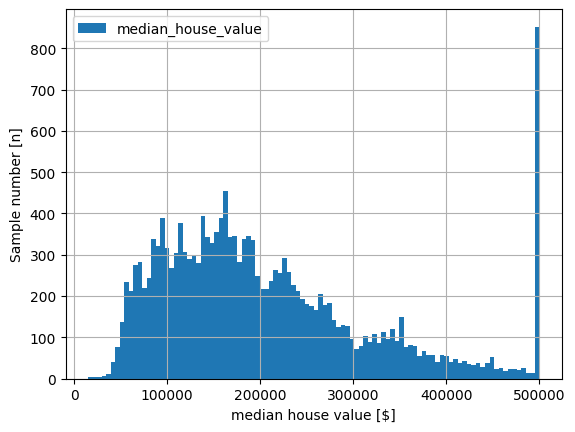

In [ ]:
df_housing.median_house_value.hist(bins=100, legend=True)
plt.xlabel("median house value [$]")
plt.ylabel("Sample number [n]")

## Split a dataset with scikit-learn
Split the housing dataset into a training set and a test set. 
Your target variable is `median_house_value`, all other features in the dataset are your independent variables (also called predictors)

Tasks:
- Split the housing dataset into a dataframe containing the independent variables and a dataframe/series containing the target variable
- Then split them into training and test set. Decide for a good ratio between training and test samples. Make sure to split your data randomly. The split and the shuffle of the data should be reproducible, i.e. return always the same random order (i.e. the same division into train and test set)
- Print the number of samples in the training and test sets

Note: Several approaches exist to apply the above steps


In [ ]:
## define the dependent and independent variable(s)
X = df_housing.drop(["median_house_value"], axis=1)
y = df_housing["median_house_value"]

# 1st approach
##  shuffle data, train and test set split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# # 2nd approach:
# ## shuffle data, e.g. by using sample()
# df_housing = df_housing.sample(frac=0.1, random_state=42) # Take all data and shuffle the order

# ## train and test set split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, shuffle=False
#   )

print(X_train.shape[0], X_test.shape[0])

13600 3400



## Load a shapefile
Task:
- Load Westeros from Game of Thrones, the name of the dataset is `Locations.shp`
- Print out the number of castles and ruins in Westeros

In [ ]:
westeros = gpd.read_file("./data/Locations.shp")

print(f"Number of castles in westeros: {len(westeros[westeros['type'] == 'Castle'])}")
print(f"Number of ruins in westeros: {len(westeros[westeros['type'] == 'Ruin'])}")

Number of castles in westeros: 114
Number of ruins in westeros: 28


## Load a GeoTiff

1. Load the `Westeros-dtm.tif`, it is just one raster band
2. Display the band , e.g. by using `matplotlib`

In [ ]:
# 1.
with rio.open("./data/Westeros_dtm.tif", mode="r") as src:
    data = src.read(1)  # Read the first band (array 2D)
    print(src.profile)  # Print  metadata incl. the shape of the raster sceje

# 2.
plt.imshow(data, cmap="terrain")
plt.show()

NameError: name 'rio' is not defined

## Load mulitple GeoTiffs

Load and display multiple Landsat bands.

Tasks:
1. Load the individual `tif` files into one 3-dimensional array, e.g. by using `rasterio`  (check out the rasterio documentation if you don't know it already). Only consider the following bands: ["B2", "B3", "B4"]. **Hint:** Consider to loop over the files and store the extracted rasters first in a list. After the loop you can convert this list into a 3-dimensional array.
2. What is the shape of your 3D-array (number of bands, columns and rows (width and length))?
3. When using classifiers in `scikit-learn` you have to reshape your data, e.g. into a dataframe. Each pixel should refer to a row in a dataframe which holds the values from the raster bands as attributes (i.e. each raster band represents a column in the dataframe). Try to convert your 3-D array to such a dataframe


In [ ]:
# 1. load the rasters and check their shapes
bands = ["B2", "B3", "B4"]
data_list = []
for b in bands:
    filename = f"./data/LC81690372015188LGN00_{b}.TIF"

    with rio.open(filename, "r") as src:
        band = src.read(1)  # 2D array of the band
        print(band.shape)  # all bands have the same shape (as expected)
    data_list.append(band)

# use numpy to convert the list of rasters into a 3D-array
data = np.array(data_list)

# 2. Shape of 3D-array containing the bands
print(data.shape)

# 3. Reshape your data and store as dataframe
samples = data.reshape((len(bands), -1)).T  # reshape into 2D-array with shape (width*length, height)
print(samples.shape)  # shape (width*length, height)

samples_df = pd.DataFrame(samples, columns=bands)
print(samples_df.tail())

(1960, 3832)
(1960, 3832)
(1960, 3832)
(3, 1960, 3832)
(7510720, 3)
            B2     B3     B4
7510715  12732  13292  14371
7510716  13026  13644  15057
7510717  13475  14488  16064
7510718  13607  14426  16142
7510719  13332  14157  15726


# Done with Exercise 1! Well done :)